### Import kebutuhan model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

### Load Dataset

In [2]:
file_path = 'dataset_2.csv'
df = pd.read_csv(file_path)

### Inspect data awal dan akhir

In [3]:
print("--- 5 Data Teratas ---")
print(df.head())
print("\n--- 5 Data Terbawah ---")
print(df.tail())

--- 5 Data Teratas ---
     Country  Age   BMI  Cholesterol  Systolic_BP  Diastolic_BP  \
0         UK   58  29.5          230          160            79   
1      Spain   34  36.2          201          120            84   
2  Indonesia   73  18.2          173          156            60   
3     Canada   60  20.3          183          122            94   
4     France   73  21.8          296           91            97   

  Smoking_Status  Alcohol_Intake Physical_Activity_Level Family_History  ...  \
0          Never            27.9                     Low            Yes  ...   
1          Never            27.5                    High            Yes  ...   
2        Current             1.8                    High            Yes  ...   
3          Never            11.6                Moderate            Yes  ...   
4          Never            29.1                Moderate            Yes  ...   

  Sleep_Duration  Heart_Rate  LDL  HDL  Triglycerides  Glucose  Gender  \
0            6.1   

### Cek missing values

In [4]:
print(df.isnull().sum())

Country                    0
Age                        0
BMI                        0
Cholesterol                0
Systolic_BP                0
Diastolic_BP               0
Smoking_Status             0
Alcohol_Intake             0
Physical_Activity_Level    0
Family_History             0
Diabetes                   0
Stress_Level               0
Salt_Intake                0
Sleep_Duration             0
Heart_Rate                 0
LDL                        0
HDL                        0
Triglycerides              0
Glucose                    0
Gender                     0
Education_Level            0
Employment_Status          0
Hypertension               0
dtype: int64


### Preprocessing dan Encoding data

In [5]:
# Menghapus kolom 'Country'
df = df.drop(columns=['Country', 'Education_Level', 'Employment_Status'])

# Encoding data kategorikal menjadi numerik
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

C:\Users\Asus\AppData\Local\Temp\ipykernel_9676\3401127071.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


### Memisahkan fitur X dan  target Y

In [6]:
X = df.drop(columns=['Hypertension'])
y = df['Hypertension']

### Buat model DT

In [58]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=12, random_state=42)

# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'max_depth': [5, 10, 15, None],
#     'min_samples_split': [2, 5, 10],
#     'criterion': ['gini', 'entropy']
# }

# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')
# grid_search.fit(X, y)

# print("Parameter Terbaik:", grid_search.best_params_)
# # Gunakan model terbaik hasil grid search
# model = grid_search.best_estimator_

### Menerapan K-Fold Cross Validation, dengan K = 5

In [59]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- Memulai K-Fold Cross Validation ---")
cv_results = cross_val_score(model, X, y, cv=kf)

print(f"Akurasi tiap Lipatan (Fold): {cv_results}")
print(f"Rata-rata Akurasi: {cv_results.mean() * 100:.2f}%")


--- Memulai K-Fold Cross Validation ---
Akurasi tiap Lipatan (Fold): [0.70906078 0.71460411 0.70610927 0.71256715 0.70870957]
Rata-rata Akurasi: 71.02%


### Evaluasi Model dengan Confsion Matrix

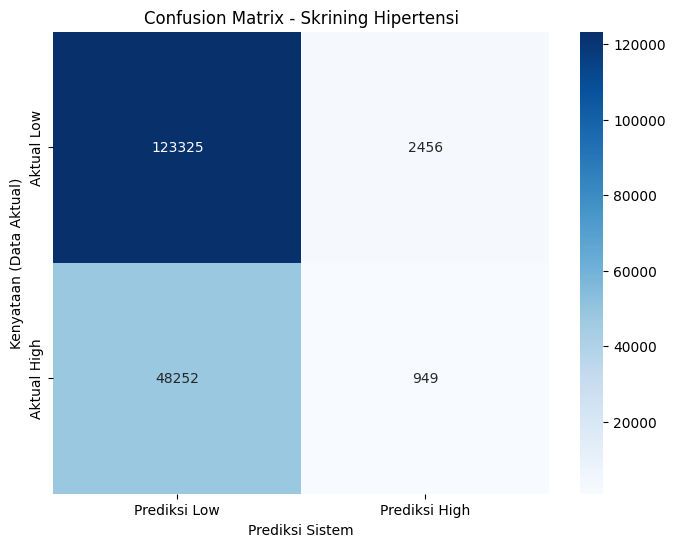

In [60]:
y_pred = cross_val_predict(model, X, y, cv=kf)

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prediksi Low', 'Prediksi High'], 
            yticklabels=['Aktual Low', 'Aktual High'])
plt.title('Confusion Matrix - Skrining Hipertensi')
plt.xlabel('Prediksi Sistem')
plt.ylabel('Kenyataan (Data Aktual)')
plt.show()

### Classification Report

In [61]:
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y, y_pred))


--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           0       0.72      0.98      0.83    125781
           1       0.28      0.02      0.04     49201

    accuracy                           0.71    174982
   macro avg       0.50      0.50      0.43    174982
weighted avg       0.60      0.71      0.61    174982



### Visualisasi

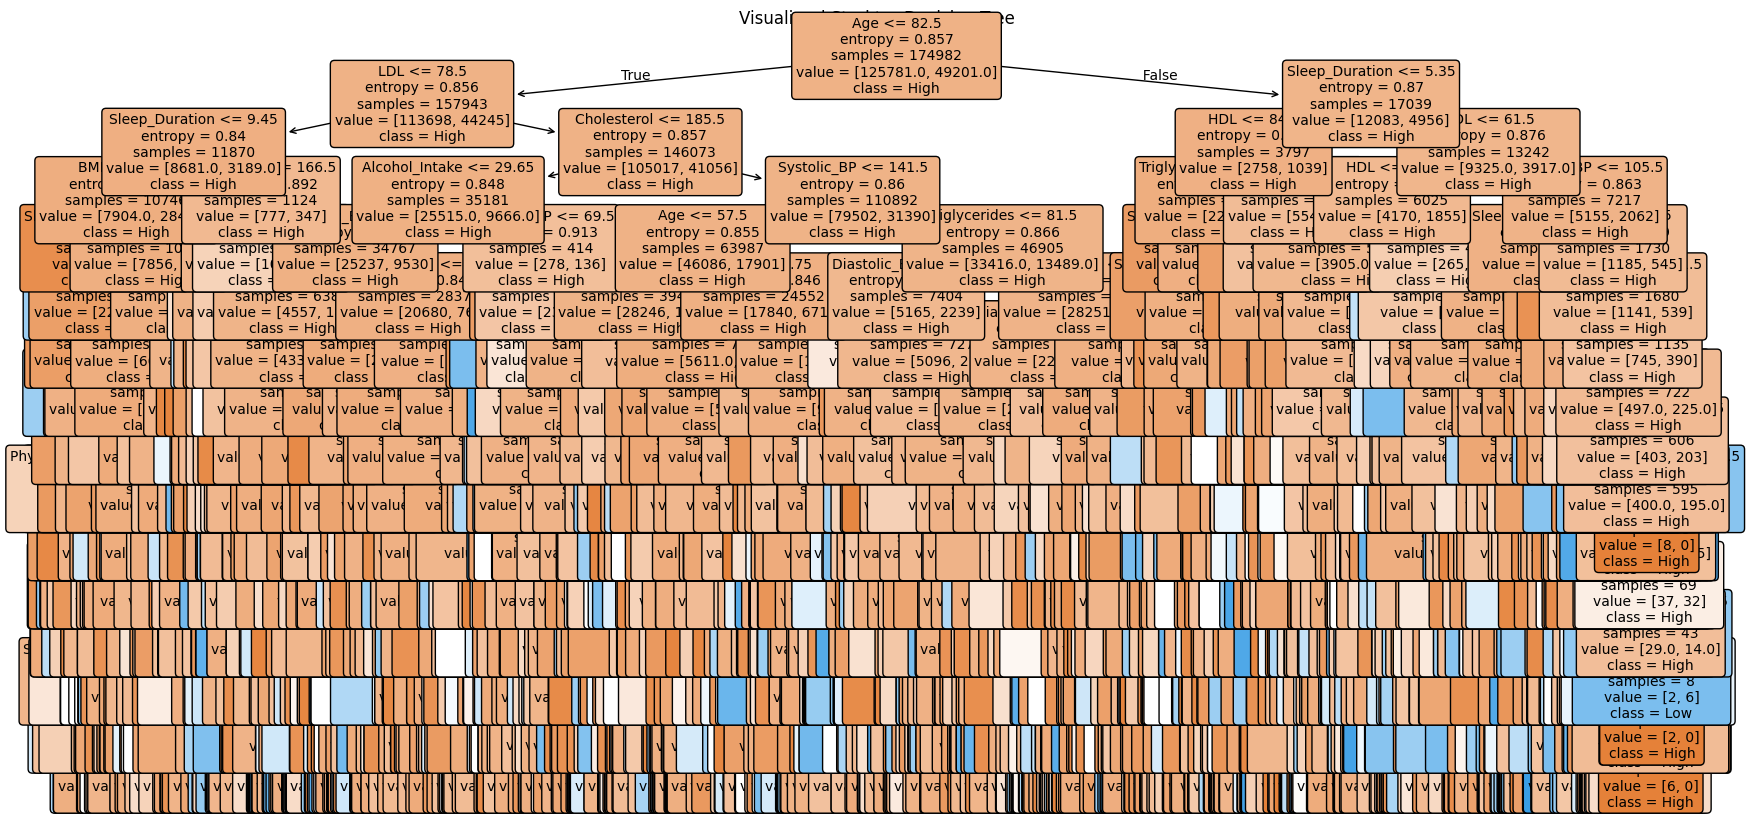

In [57]:
plt.figure(figsize=(20,10))
plot_tree(model.fit(X, y), feature_names=X.columns, 
          class_names=['High', 'Low'], filled=True, rounded=True, fontsize=10)
plt.title("Visualisasi Struktur Decision Tree")
plt.show()